In [1]:
import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.applications import MobileNetV3Small, MobileNetV3Large
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom
from sklearn.metrics import confusion_matrix, classification_report

In [12]:
DATASET_DIR = "../dataset_stage1"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 25
SEED = 42

In [13]:
data_augmentation = tf.keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1),
])

In [14]:
train_ds = image_dataset_from_directory(
    os.path.join(DATASET_DIR, "train"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True,
    seed=SEED
)

train_ds = train_ds.map(
    lambda x, y: (data_augmentation(preprocess_input(x)), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

val_ds = image_dataset_from_directory(
    os.path.join(DATASET_DIR, "val"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

val_ds = val_ds.map(
    lambda x, y: (preprocess_input(x), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

test_ds = image_dataset_from_directory(
    os.path.join(DATASET_DIR, "test"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

test_ds = test_ds.map(
    lambda x, y: (preprocess_input(x), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

Found 1600 files belonging to 2 classes.
Found 200 files belonging to 2 classes.
Found 200 files belonging to 2 classes.


In [15]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

Load pretrained MobileNetV3

In [16]:
base_model = MobileNetV3Large(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

Add classification head

In [17]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.2)(x)
output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=output)

Compile model

In [18]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

In [19]:
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ input_layer_3[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv (Conv2D)       │ (None, 112, 112,  │        432 │ rescaling_1[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_bn             │ (None, 112, 112,  │         64 │ conv[0][0]        │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_20       │ (None, 112, 112,  │          0 │ conv_bn[0][0]     │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        144 │ activation_20[0]… │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_19 (ReLU)     │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        256 │ re_lu_19[0][0]    │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_add   │ (None, 112, 112,  │          0 │ activation_20[0]… │
│ (Add)               │ 16)               │            │ expanded_conv_pr… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_ex… │ (None, 112, 112,  │      1,024 │ expanded_conv_ad… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_ex… │ (None, 112, 112,  │        256 │ expanded_conv_1_… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_20 (ReLU)     │ (None, 112, 112,  │          0 │ expanded_conv_1_… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 113, 113,  │          0 │ re_lu_20[0][0]    │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 56, 56,    │        576 │ expanded_conv_1_… │
│ (DepthwiseConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 56, 56,    │        256 │ expanded_conv_1_

 Total params: 2,997,313 (11.43 MB)

 Trainable params: 961 (3.75 KB)

 Non-trainable params: 2,996,352 (11.43 MB)

In [20]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 54s 886ms/step - accuracy: 0.6988 - loss: 0.5988 - precision_1: 0.6939 - recall_1: 0.7113 - val_accuracy: 0.7600 - val_loss: 0.4632 - val_precision_1: 0.7500 - val_recall_1: 0.7800
Epoch 2/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 33s 645ms/step - accuracy: 0.7950 - loss: 0.4314 - precision_1: 0.7914 - recall_1: 0.8012 - val_accuracy: 0.8400 - val_loss: 0.3744 - val_precision_1: 0.8269 - val_recall_1: 0.8600
Epoch 3/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 32s 635ms/step - accuracy: 0.8575 - loss: 0.3450 - precision_1: 0.8429 - recall_1: 0.8788 - val_accuracy: 0.8550 - val_loss: 0.3311 - val_precision_1: 0.8318 - val_recall_1: 0.8900
Epoch 4/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 37s 734ms/step - accuracy: 0.8750 - loss: 0.2990 - precision_1: 0.8713 - recall_1: 0.8800 - val_accuracy: 0.8600 - val_loss: 0.2991 - val_precision_1: 0.8333 - val_recall_1: 0.9000
Epoch 5/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 44s 768ms/step - accuracy: 0.8806 - loss: 0.2870 - precision_1: 0.8727 - recall_1: 0.8

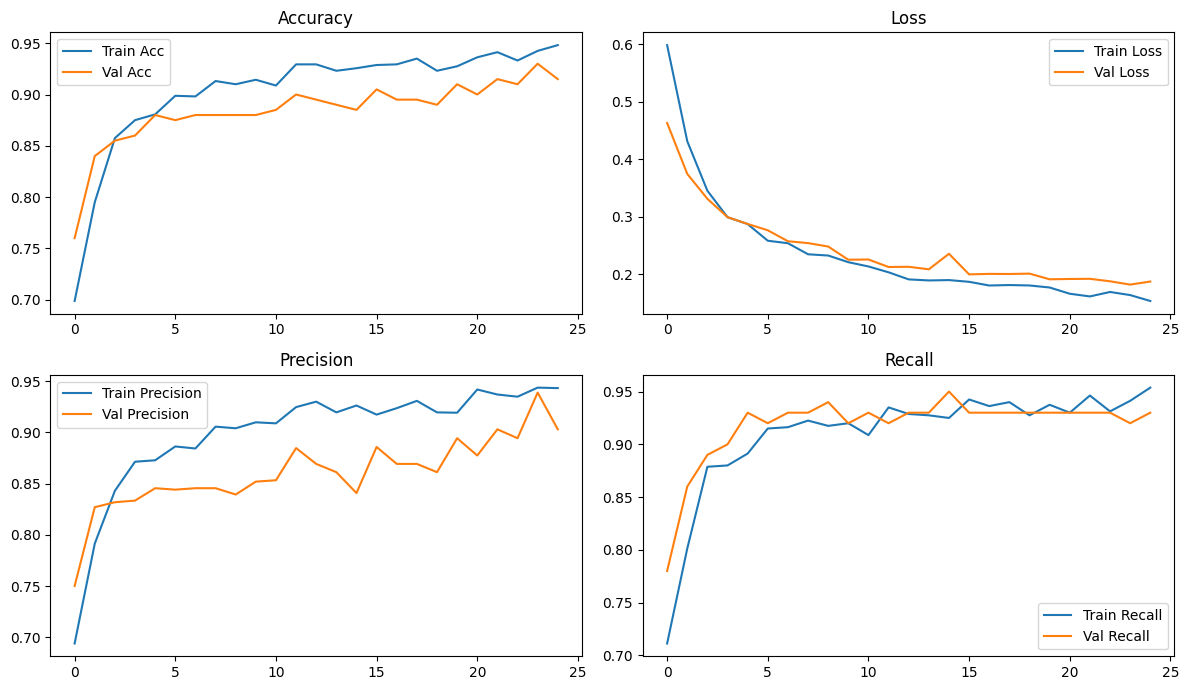

In [23]:
plt.figure(figsize=(12, 7))

# Accuracy
plt.subplot(2, 2, 1)
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.legend()
plt.title("Accuracy")

# Loss
plt.subplot(2, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss")

# Precision
plt.subplot(2, 2, 3)
plt.plot(history.history["precision_1"], label="Train Precision")
plt.plot(history.history["val_precision_1"], label="Val Precision")
plt.legend()
plt.title("Precision")

# Recall
plt.subplot(2, 2, 4)
plt.plot(history.history["recall_1"], label="Train Recall")
plt.plot(history.history["val_recall_1"], label="Val Recall")
plt.legend()
plt.title("Recall")

plt.tight_layout()
plt.show()

7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step 


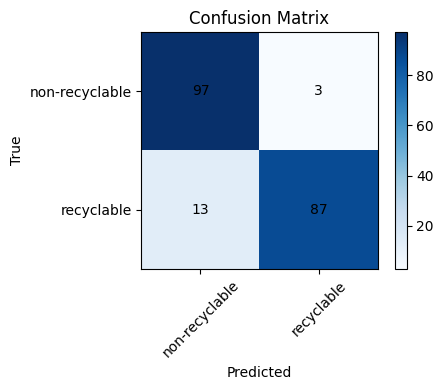

                precision    recall  f1-score   support

non-recyclable       0.88      0.97      0.92       100
    recyclable       0.97      0.87      0.92       100

      accuracy                           0.92       200
     macro avg       0.92      0.92      0.92       200
  weighted avg       0.92      0.92      0.92       200



In [24]:
# Collect ground-truth labels
y_true = np.concatenate([y for _, y in test_ds], axis=0)

# Predict probabilities
y_prob = model.predict(test_ds).ravel()
y_pred = (y_prob >= 0.5).astype(int)

# Class labels
class_names = ["non-recyclable", "recyclable"]

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.yticks(range(len(class_names)), class_names)
plt.colorbar()
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")
plt.tight_layout()
plt.show()

# Classification report
print(classification_report(y_true, y_pred, target_names=class_names))

In [25]:
test_results = model.evaluate(test_ds)

7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 452ms/step - accuracy: 0.9200 - loss: 0.2019 - precision_1: 0.9667 - recall_1: 0.8700    


In [26]:
model.save("model/stage1_mobilenetv3_1.keras")